# Olist E-Commerce Data Analysis
## Project Overview
This project analyzes 100,000+ real orders from Olist, 
Brazil's largest e-commerce platform (2016-2018).

## Business Questions Answered
1. What is the total revenue and growth trend?
2. Which product categories drive the most revenue?
3. How does delivery performance vary by state?
4. Does late delivery affect customer ratings?
5. Who are our most valuable customers? (RFM Analysis)

## Tools Used
- Python (Pandas, Matplotlib, Seaborn)
- SQL (SQLite)
- Jupyter Notebook

## Key Findings
- $15.4M total revenue over 2 years
- 10x growth in 2017
- Late deliveries score 40% lower reviews
- 24% of customers are at risk of leaving

In [1]:
import pandas as pd

# Set the path to your data folder
path = '/home/payallsingh/Olist-dataset-anaylsis/olist dataset/'

# Load all datasets
orders = pd.read_csv(path + 'olist_orders_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
geolocation = pd.read_csv(path + 'olist_geolocation_dataset.csv')
translation = pd.read_csv(path + 'product_category_name_translation.csv')

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [2]:
print("Orders:     ",orders.shape)
print("Customers:  ",customers.shape)
print("Payments:   ",payments.shape)
print("Order Items:",order_items.shape)
print("Products:   ",products.shape)
print("Sellers:    ",sellers.shape)
print("Reviews:    ",reviews.shape)
print("Geolocation:",geolocation.shape)
print("Translation:",translation.shape)

Orders:      (99441, 8)
Customers:   (99441, 5)
Payments:    (103886, 5)
Order Items: (112650, 7)
Products:    (32951, 9)
Sellers:     (3095, 4)
Reviews:     (99224, 7)
Geolocation: (1000163, 5)
Translation: (71, 2)


In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
print("=========Missing Values=========")
print("\nOrders\n\n",orders.isnull().sum())
print("\n\nCustomers\n\n",customers.isnull().sum())
print("\n\nPayments\n\n",payments.isnull().sum())
print("\n\nReviews\n\n",reviews.isnull().sum())


=========Missing Values=========

Orders

 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


Customers

 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


Payments

 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


Reviews

 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [5]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print("First order:  ",orders['order_purchase_timestamp'].min())

print("Last order:   ",orders['order_purchase_timestamp'].max())

First order:   2016-09-04 21:15:19
Last order:    2018-10-17 17:30:18


In [7]:
delivered_orders = orders[orders['order_status'] == 'delivered']
print("Delivered orders:", len(delivered_orders))

Delivered orders: 96478


In [8]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [9]:
# Run this cell only ONCE to create the database
# After that, just use the connection cell below

import sqlite3

# Create a database file in your project folder
conn = sqlite3.connect('../olist.db')

# Load all tables into the database
orders.to_sql('orders', conn, if_exists='replace', index=False)
customers.to_sql('customers', conn, if_exists='replace', index=False)
payments.to_sql('payments', conn, if_exists='replace', index=False)
order_items.to_sql('order_items', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
sellers.to_sql('sellers', conn, if_exists='replace', index=False)
reviews.to_sql('reviews', conn, if_exists='replace', index=False)
translation.to_sql('translation', conn, if_exists='replace', index=False)

print("Database created successfully!")
conn.close()

Database created successfully!


In [10]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect('/home/payallsingh/Olist-dataset-anaylsis/olist.db')

# Total revenue from delivered orders
query = """
SELECT 
    ROUND(SUM(payment_value), 2) AS total_revenue
FROM payments p
JOIN orders o ON p.order_id = o.order_id
WHERE o.order_status = 'delivered';
"""

result = pd.read_sql_query(query, conn)
print(result)

   total_revenue
0    15422461.77


In [11]:
# Monthly revenue trend
query = """
SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    ROUND(SUM(p.payment_value), 2) AS revenue
FROM orders o
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY month
ORDER BY month;
"""

monthly_revenue = pd.read_sql_query(query, conn)
print(monthly_revenue)


      month     revenue
0   2016-10    46566.71
1   2016-12       19.62
2   2017-01   127545.67
3   2017-02   271298.65
4   2017-03   414369.39
5   2017-04   390952.18
6   2017-05   567066.73
7   2017-06   490225.60
8   2017-07   566403.93
9   2017-08   646000.61
10  2017-09   701169.99
11  2017-10   751140.27
12  2017-11  1153528.05
13  2017-12   843199.17
14  2018-01  1078606.86
15  2018-02   966510.88
16  2018-03  1120678.00
17  2018-04  1132933.95
18  2018-05  1128836.69
19  2018-06  1012090.68
20  2018-07  1027903.86
21  2018-08   985414.28


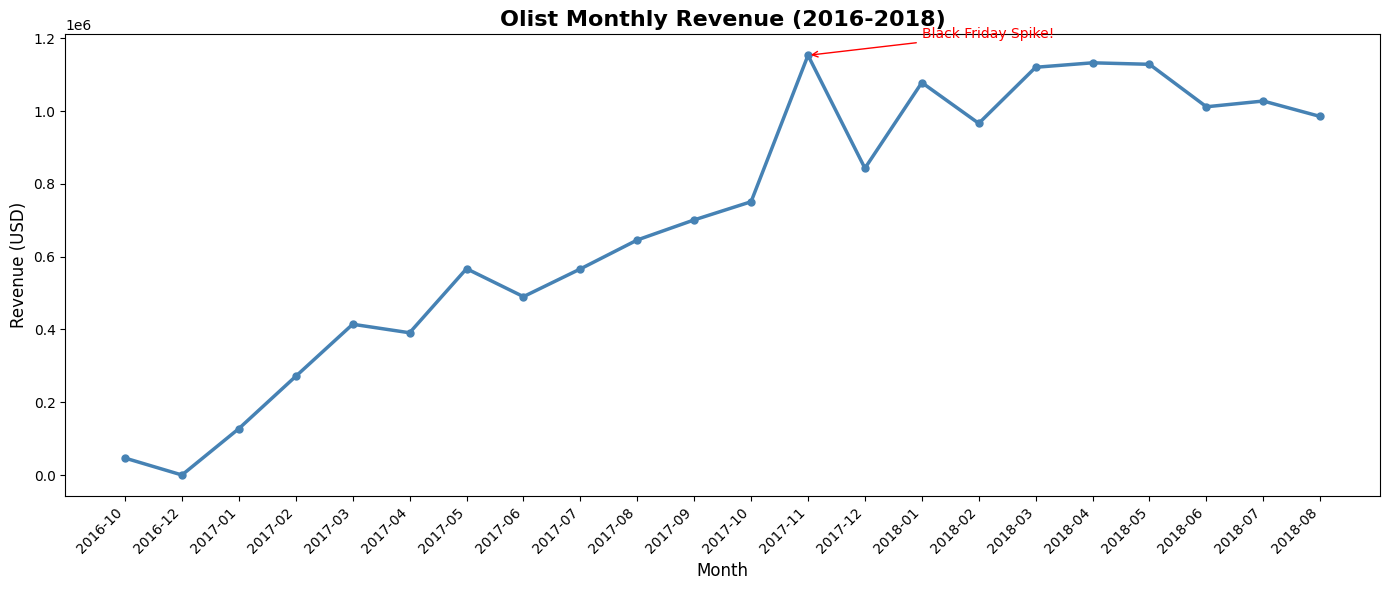

Chart saved!


In [12]:
import os
import matplotlib.pyplot as plt

# Create visuals folder if it doesn't exist
visuals_path = '/home/payallsingh/Olist-dataset-anaylsis/visuals/'
os.makedirs(visuals_path, exist_ok=True)

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'], 
         marker='o', color='steelblue', linewidth=2.5, markersize=5)

plt.xticks(rotation=45, ha='right')

plt.title('Olist Monthly Revenue (2016-2018)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (USD)', fontsize=12)

plt.annotate('Black Friday Spike!', 
             xy=(12, 1153528), 
             xytext=(14, 1200000),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

plt.tight_layout()
plt.savefig(visuals_path + 'monthly_revenue.png', dpi=150)
plt.show()

print("Chart saved!")

In [13]:
# Top 10 product categories by revenue
query = """
SELECT 
    t.product_category_name_english AS category,
    ROUND(SUM(p.payment_value), 2) AS revenue,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN payments p ON o.order_id = p.order_id
JOIN products pr ON oi.product_id = pr.product_id
JOIN translation t ON pr.product_category_name = t.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY revenue DESC
LIMIT 10;
"""

top_categories = pd.read_sql_query(query, conn)
print(top_categories)

                category     revenue  total_orders
0         bed_bath_table  1692714.28          9272
1          health_beauty  1620684.04          8646
2  computers_accessories  1549372.59          6530
3        furniture_decor  1394466.93          6307
4          watches_gifts  1387362.45          5495
5         sports_leisure  1349446.93          7530
6             housewares  1069787.97          5743
7                   auto   833745.67          3810
8           garden_tools   810614.93          3448
9             cool_stuff   744649.32          3559


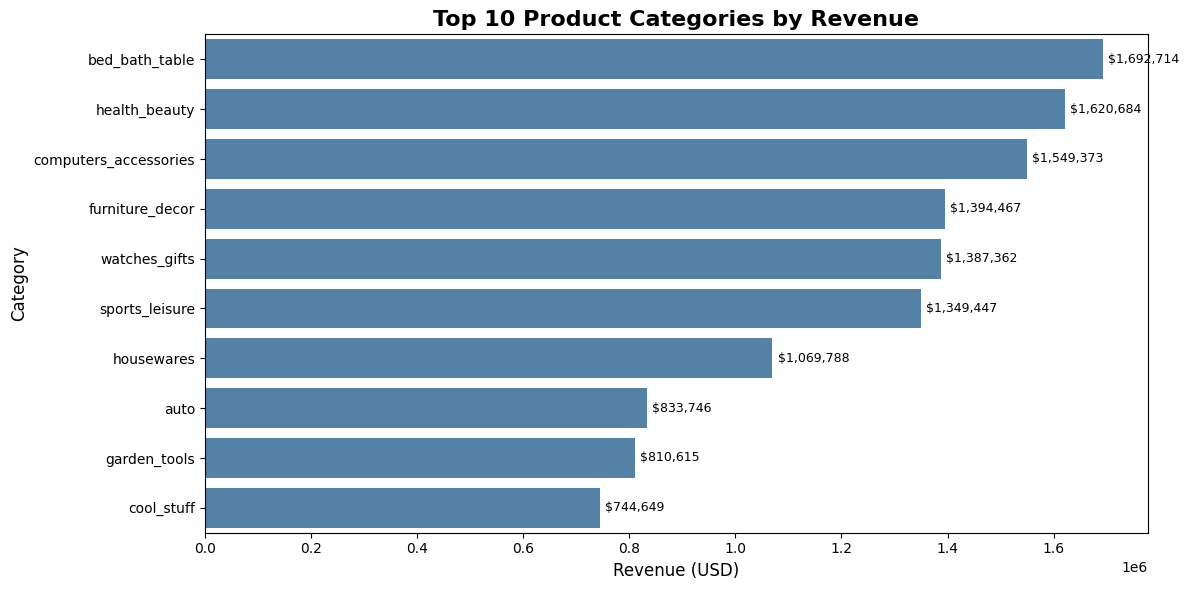

Chart saved!


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='revenue', y='category', color='steelblue')

plt.title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Revenue (USD)', fontsize=12)
plt.ylabel('Category', fontsize=12)

# Add value labels on each bar
for i, row in top_categories.iterrows():
    plt.text(row['revenue'] + 10000, i, f"${row['revenue']:,.0f}", 
             va='center', fontsize=9)

plt.tight_layout()
plt.savefig(visuals_path + 'top_categories.png', dpi=150)
plt.show()

print("Chart saved!")

In [16]:
# Average delivery time per state
query = """
SELECT 
    c.customer_state AS state,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - 
              julianday(o.order_purchase_timestamp)), 1) AS avg_delivery_days,
    COUNT(o.order_id) AS total_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY state
ORDER BY avg_delivery_days ASC
LIMIT 10;
"""

delivery_time = pd.read_sql_query(query, conn)
print(delivery_time)

  state  avg_delivery_days  total_orders
0    SP                8.8         40494
1    MG               12.0         11354
2    PR               12.0          4923
3    DF               13.0          2080
4    SC               15.0          3546
5    RJ               15.3         12350
6    RS               15.3          5344
7    GO               15.6          1957
8    MS               15.6           701
9    ES               15.8          1995


In [17]:
# Slowest delivery states
query = """
SELECT 
    c.customer_state AS state,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - 
              julianday(o.order_purchase_timestamp)), 1) AS avg_delivery_days,
    COUNT(o.order_id) AS total_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY state
ORDER BY avg_delivery_days DESC
LIMIT 10;
"""

slow_delivery = pd.read_sql_query(query, conn)
print(slow_delivery)

  state  avg_delivery_days  total_orders
0    RR               29.4            41
1    AP               27.2            67
2    AM               26.4           145
3    AL               24.5           397
4    PA               23.8           946
5    MA               21.6           717
6    SE               21.5           335
7    CE               21.3          1279
8    AC               21.0            80
9    PB               20.4           517


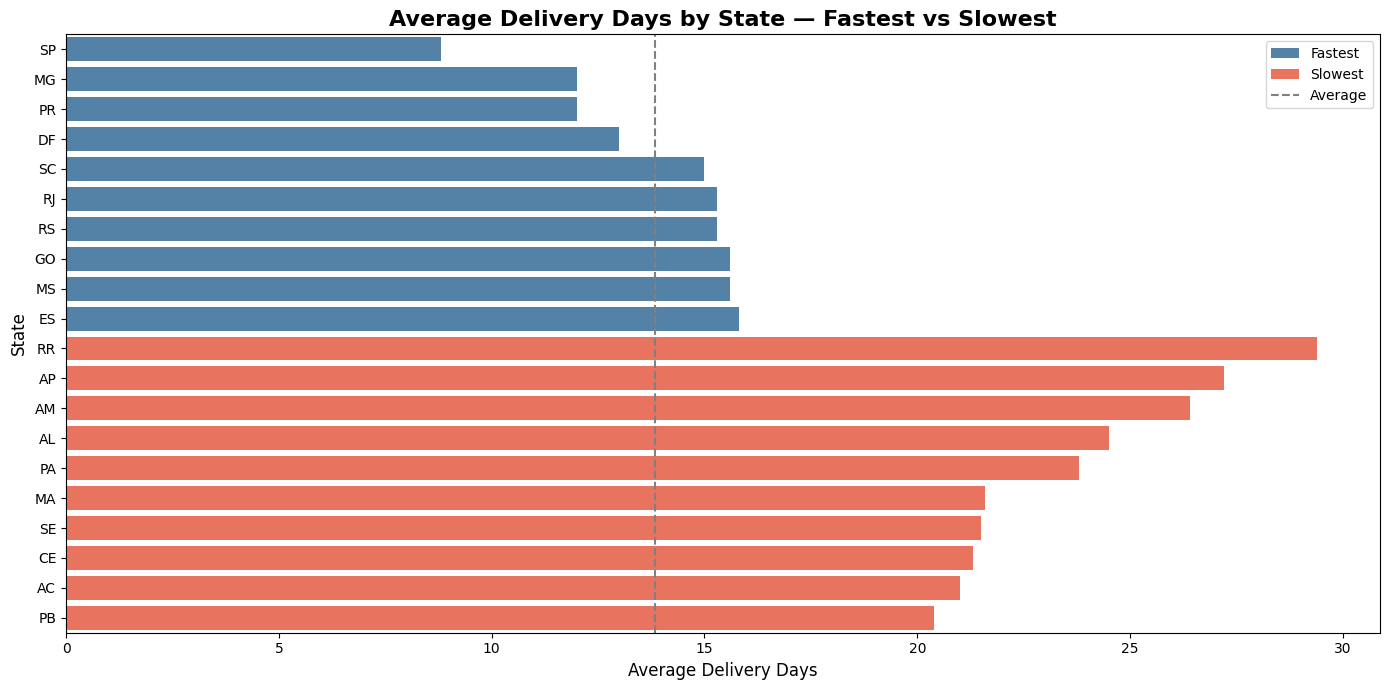

Chart saved!


In [18]:
# Combine both dataframes
delivery_time['type'] = 'Fastest'
slow_delivery['type'] = 'Slowest'
combined = pd.concat([delivery_time, slow_delivery])

plt.figure(figsize=(14, 7))
sns.barplot(data=combined, x='avg_delivery_days', y='state', 
            hue='type', palette={'Fastest':'steelblue', 'Slowest':'tomato'})

plt.title('Average Delivery Days by State — Fastest vs Slowest', 
          fontsize=16, fontweight='bold')
plt.xlabel('Average Delivery Days', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.axvline(x=delivery_time['avg_delivery_days'].mean(), 
            color='gray', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.savefig(visuals_path + 'delivery_time_by_state.png', dpi=150)
plt.show()

print("Chart saved!")

In [19]:
# Late delivery vs review score
query = """
SELECT 
    CASE 
        WHEN julianday(o.order_delivered_customer_date) <= 
             julianday(o.order_estimated_delivery_date) 
        THEN 'On Time'
        ELSE 'Late'
    END AS delivery_status,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    COUNT(o.order_id) AS total_orders
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY delivery_status;
"""

delivery_vs_reviews = pd.read_sql_query(query, conn)
print(delivery_vs_reviews)

  delivery_status  avg_review_score  total_orders
0            Late              2.57          7700
1         On Time              4.29         88653


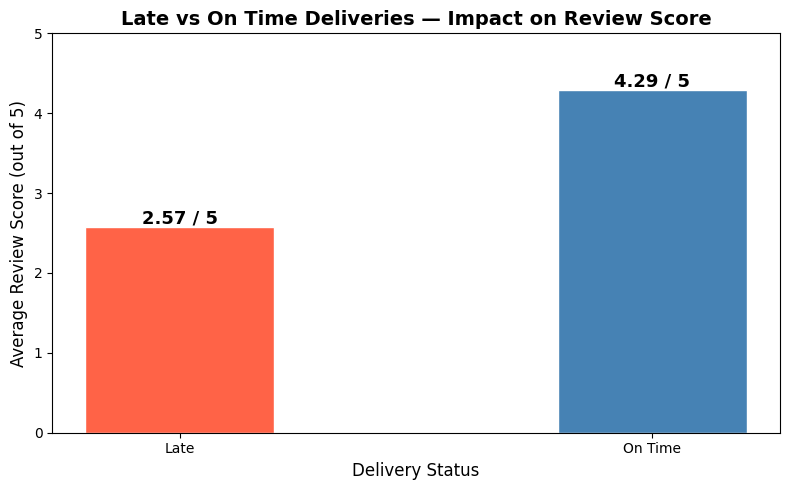

Chart saved!


In [20]:
plt.figure(figsize=(8, 5))
colors = ['tomato', 'steelblue']
bars = plt.bar(delivery_vs_reviews['delivery_status'], 
               delivery_vs_reviews['avg_review_score'],
               color=colors, width=0.4, edgecolor='white')

# Add value labels on top of bars (no emoji)
for bar, val in zip(bars, delivery_vs_reviews['avg_review_score']):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.05,
             f'{val} / 5', ha='center', fontsize=13, fontweight='bold')

plt.title('Late vs On Time Deliveries — Impact on Review Score', 
          fontsize=14, fontweight='bold')
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Average Review Score (out of 5)', fontsize=12)
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig(visuals_path + 'delivery_vs_reviews.png', dpi=150)
plt.show()

print("Chart saved!")

In [21]:
# Orders by state
query = """
SELECT 
    c.customer_state AS state,
    COUNT(o.order_id) AS total_orders,
    ROUND(SUM(p.payment_value), 2) AS total_revenue
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY state
ORDER BY total_orders DESC
LIMIT 10;
"""

orders_by_state = pd.read_sql_query(query, conn)
print(orders_by_state)

  state  total_orders  total_revenue
0    SP         42308     5770266.19
1    RJ         13004     2055690.45
2    MG         11804     1819277.61
3    RS          5544      861802.40
4    PR          5129      781919.55
5    SC          3661      595208.40
6    BA          3483      591270.60
7    DF          2142      346146.17
8    ES          2068      317682.65
9    GO          2047      334294.22


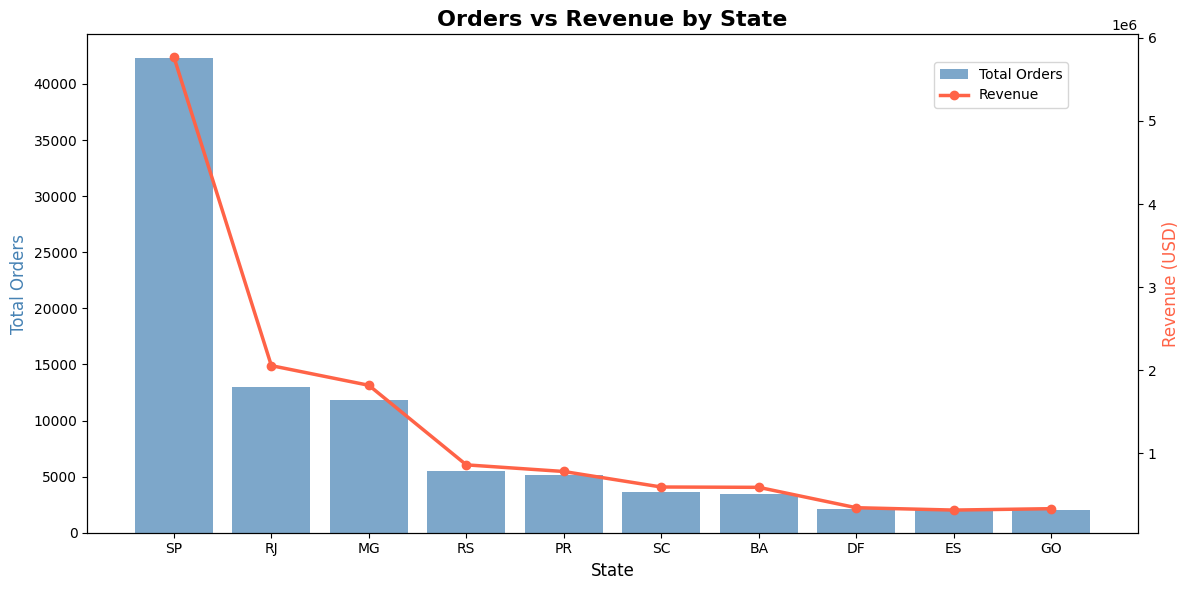

Chart saved!


In [22]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(orders_by_state))

# Bar chart for orders
ax1.bar(x, orders_by_state['total_orders'], 
        color='steelblue', alpha=0.7, label='Total Orders')
ax1.set_xlabel('State', fontsize=12)
ax1.set_ylabel('Total Orders', fontsize=12, color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(orders_by_state['state'])

# Line chart for revenue on second axis
ax2 = ax1.twinx()
ax2.plot(x, orders_by_state['total_revenue'], 
         color='tomato', marker='o', linewidth=2.5, label='Revenue')
ax2.set_ylabel('Revenue (USD)', fontsize=12, color='tomato')

plt.title('Orders vs Revenue by State', fontsize=16, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.savefig(visuals_path + 'orders_by_state.png', dpi=150)
plt.show()

print("Chart saved!")

In [ ]:
# RFM Customer Segmentation.

In [28]:
# First merge orders with payments to get customer spending
query = """
SELECT 
    c.customer_unique_id,
    o.order_purchase_timestamp,
    o.order_id,
    p.payment_value
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
"""

rfm_data = pd.read_sql_query(query, conn)
rfm_data['order_purchase_timestamp'] = pd.to_datetime(rfm_data['order_purchase_timestamp'])

print("RFM data shape:", rfm_data.shape)
print(rfm_data.head())

RFM data shape: (100756, 4)
                 customer_unique_id order_purchase_timestamp  \
0  7c396fd4830fd04220f754e42b4e5bff      2017-10-02 10:56:33   
1  7c396fd4830fd04220f754e42b4e5bff      2017-10-02 10:56:33   
2  7c396fd4830fd04220f754e42b4e5bff      2017-10-02 10:56:33   
3  af07308b275d755c9edb36a90c618231      2018-07-24 20:41:37   
4  3a653a41f6f9fc3d2a113cf8398680e8      2018-08-08 08:38:49   

                           order_id  payment_value  
0  e481f51cbdc54678b7cc49136f2d6af7           2.00  
1  e481f51cbdc54678b7cc49136f2d6af7          18.12  
2  e481f51cbdc54678b7cc49136f2d6af7          18.59  
3  53cdb2fc8bc7dce0b6741e2150273451         141.46  
4  47770eb9100c2d0c44946d9cf07ec65d         179.12  


In [29]:
#group payments per order 
rfm_data_grouped = rfm_data.groupby(
    ['customer_unique_id', 'order_id', 'order_purchase_timestamp']
)['payment_value'].sum().reset_index()

print("After grouping:", rfm_data_grouped.shape)
print(rfm_data_grouped.head())

After grouping: (96477, 4)
                 customer_unique_id                          order_id  \
0  0000366f3b9a7992bf8c76cfdf3221e2  e22acc9c116caa3f2b7121bbb380d08e   
1  0000b849f77a49e4a4ce2b2a4ca5be3f  3594e05a005ac4d06a72673270ef9ec9   
2  0000f46a3911fa3c0805444483337064  b33ec3b699337181488304f362a6b734   
3  0000f6ccb0745a6a4b88665a16c9f078  41272756ecddd9a9ed0180413cc22fb6   
4  0004aac84e0df4da2b147fca70cf8255  d957021f1127559cd947b62533f484f7   

  order_purchase_timestamp  payment_value  
0      2018-05-10 10:56:27         141.90  
1      2018-05-07 11:11:27          27.19  
2      2017-03-10 21:05:03          86.22  
3      2017-10-12 20:29:41          43.62  
4      2017-11-14 19:45:42         196.89  


In [30]:
import datetime

# Set snapshot date (day after last order)
snapshot_date = rfm_data_grouped['order_purchase_timestamp'].max() + datetime.timedelta(days=1)
print("Snapshot date:", snapshot_date)

# Calculate RFM values
rfm = rfm_data_grouped.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'count'),
    Monetary=('payment_value', 'sum')
).reset_index()

print("\nRFM Table:")
print(rfm.head(10))
print("\nRFM Stats:")
print(rfm.describe())

Snapshot date: 2018-08-30 15:00:37

RFM Table:
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38
7  00053a61a98854899e70ed204dd4bafe      183          1    419.18
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76

RFM Stats:
            Recency     Frequency      Monetary
count  93357.000000  93357.000000  93357.000000
mean     237.936673      1.033420    165.198772
std      152.584315      0.209099    226.314579
min        1.000000    

In [31]:
# Score each customer 1-5
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])

# Combine scores into one RFM score
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm[['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'RFM_Score']].head(10))

                 customer_unique_id  Recency  Frequency  Monetary RFM_Score
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90       414
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19       411
2  0000f46a3911fa3c0805444483337064      537          1     86.22       112
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62       211
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89       214
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98       414
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38       411
7  00053a61a98854899e70ed204dd4bafe      183          1    419.18       315
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12       114
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76       413


In [32]:
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'          # Best customers
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'    # Buy regularly
    elif r >= 4 and f <= 2:
        return 'New Customers'      # Bought recently but not often
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'# Could become loyal
    elif r <= 2 and f >= 3:
        return 'At Risk'            # Used to buy often but stopped
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'     # High spenders going inactive
    else:
        return 'Lost'               # Haven't bought in long time

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# See segment distribution
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

Segment
Loyal Customers        27292
At Risk                22229
New Customers          14984
Cant Lose Them          8671
Potential Loyalists     7373
Champions               6493
Lost                    6315
Name: count, dtype: int64


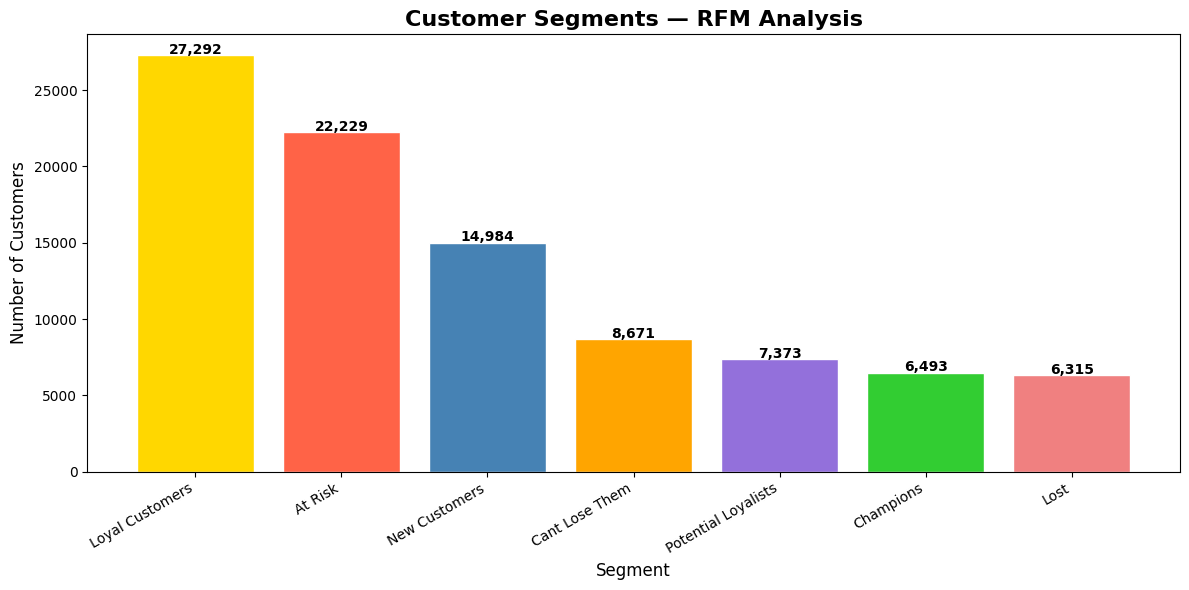

Chart saved!


In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
colors = ['gold', 'tomato', 'steelblue', 'orange', 'mediumpurple', 'limegreen', 'lightcoral']

bars = plt.bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='white')

# Add value labels on top of bars
for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.title('Customer Segments — RFM Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(visuals_path + 'customer_segments.png', dpi=150)
plt.show()

print("Chart saved!")


In [34]:
# Average RFM values per segment
segment_summary = rfm.groupby('Segment').agg(
    Total_Customers=('customer_unique_id', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2).reset_index()

print(segment_summary.sort_values('Avg_Monetary', ascending=False))

               Segment  Total_Customers  Avg_Recency  Avg_Frequency  \
2            Champions             6493        91.11           1.18   
1       Cant Lose Them             8671       394.55           1.00   
0              At Risk            22229       394.65           1.05   
5        New Customers            14984        90.88           1.00   
6  Potential Loyalists             7373       220.24           1.00   
4      Loyal Customers            27292       144.23           1.03   
3                 Lost             6315       396.82           1.00   

   Avg_Monetary  
2        312.13  
1        240.98  
0        166.98  
5        163.43  
6        154.01  
4        134.02  
3         55.83  


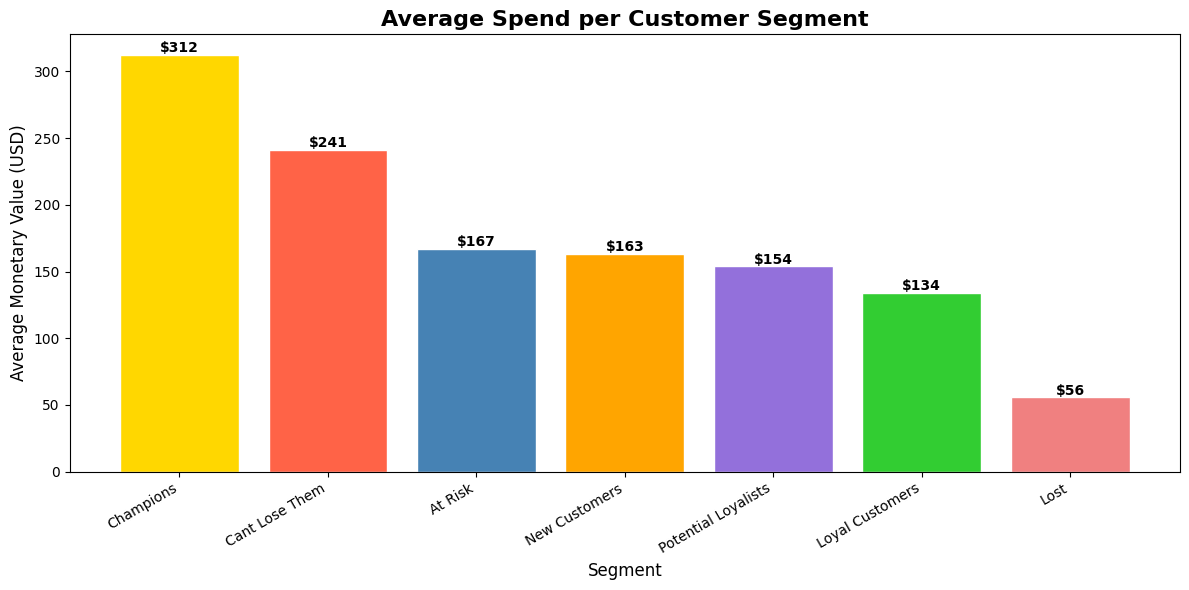

Chart saved!


In [35]:
plt.figure(figsize=(12, 6))
colors = ['gold', 'tomato', 'steelblue', 'orange', 'mediumpurple', 'limegreen', 'lightcoral']

bars = plt.bar(segment_summary.sort_values('Avg_Monetary', ascending=False)['Segment'],
               segment_summary.sort_values('Avg_Monetary', ascending=False)['Avg_Monetary'],
               color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, segment_summary.sort_values('Avg_Monetary', ascending=False)['Avg_Monetary']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.title('Average Spend per Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Average Monetary Value (USD)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(visuals_path + 'segment_value.png', dpi=150)
plt.show()

print("Chart saved!")

In [36]:
# Review score distribution
query = """
SELECT 
    review_score,
    COUNT(*) AS total_reviews,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM reviews r
JOIN orders o ON r.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY review_score
ORDER BY review_score;
"""

review_dist = pd.read_sql_query(query, conn)
print(review_dist)

   review_score  total_reviews  percentage
0             1           9406        9.76
1             2           2941        3.05
2             3           7961        8.26
3             4          18987       19.70
4             5          57066       59.22


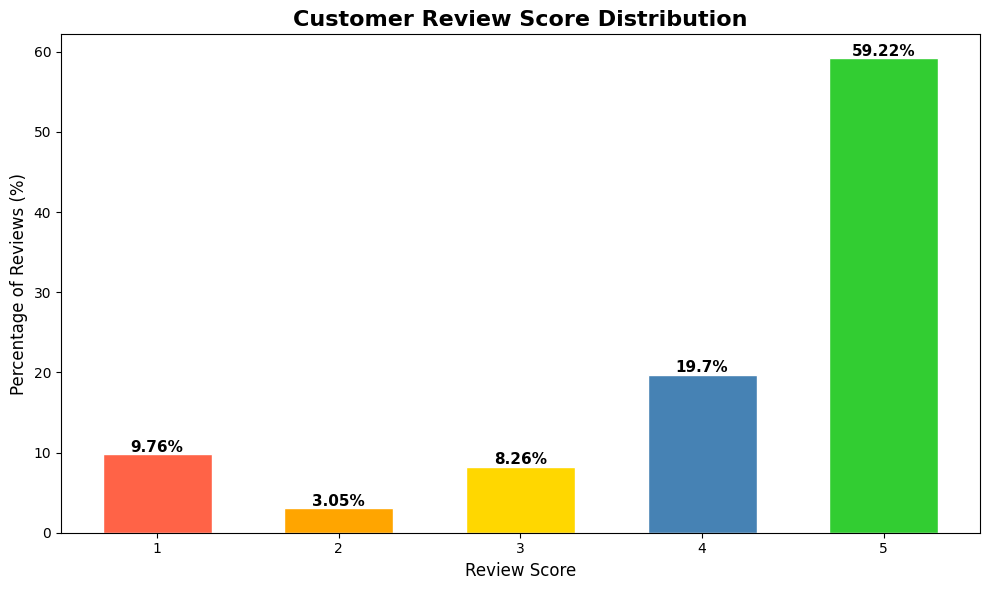

Chart saved!


In [37]:
plt.figure(figsize=(10, 6))
colors = ['tomato', 'orange', 'gold', 'steelblue', 'limegreen']

bars = plt.bar(review_dist['review_score'], 
               review_dist['percentage'],
               color=colors, edgecolor='white', width=0.6)

# Add percentage labels
for bar, val in zip(bars, review_dist['percentage']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=11, fontweight='bold')

plt.title('Customer Review Score Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Percentage of Reviews (%)', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig(visuals_path + 'review_distribution.png', dpi=150)
plt.show()

print("Chart saved!")

In [38]:
print("""
========================================
OLIST E-COMMERCE — KEY BUSINESS INSIGHTS
========================================

1. REVENUE
   - Total revenue: $15.4M over 2 years
   - 10x growth from Jan 2017 to Nov 2017
   - Black Friday 2017 was biggest month ($1.15M)
   - Revenue stabilized at ~$1M/month in 2018

2. PRODUCT CATEGORIES
   - Bed & Bath is #1 category ($1.69M)
   - Computers have fewer orders but higher value per order
   - Sports & Leisure has high orders but low revenue per order

3. DELIVERY & LOGISTICS
   - Sao Paulo delivers in 8.8 days (fastest)
   - Northern states wait 29+ days (3x slower)
   - 8% of orders are delivered late
   - Late deliveries score 2.57 stars vs 4.29 for on time

4. CUSTOMER SEGMENTS
   - 93,357 unique customers analyzed
   - 29% are Loyal Customers (biggest segment)
   - 24% are At Risk of leaving
   - Champions spend $312 on average (highest)
   - Can't Lose Them spend $240 but inactive for 1+ year

5. CUSTOMER SATISFACTION
   - 79% of customers gave 4-5 stars
   - 10% gave 1 star (very unhappy)
   - Main driver of bad reviews = late delivery

========================================
BUSINESS RECOMMENDATIONS
========================================

1. Fix northern state logistics
   - Open fulfillment centers in AM, PA, RR
   - Partner with local delivery companies
   - Target: reduce delivery time to under 15 days nationwide

2. Win back Can't Lose Them segment
   - 8,671 high value customers inactive for 1+ year
   - Send personalized discount (15-20% off)
   - Potential revenue recovery: ~$2M

3. Convert New Customers to Loyal
   - 14,984 customers bought once recently
   - Send follow up email within 30 days
   - Show related products to their first purchase

4. Reward Champions
   - Only 6,493 customers but highest spenders
   - Create VIP loyalty program
   - Early access to new products, free shipping

5. Reduce late deliveries
   - Currently 8% late delivery rate
   - Each late delivery risks a 1 star review
   - Target: reduce to under 3% late deliveries
""")


OLIST E-COMMERCE — KEY BUSINESS INSIGHTS

1. REVENUE
   - Total revenue: $15.4M over 2 years
   - 10x growth from Jan 2017 to Nov 2017
   - Black Friday 2017 was biggest month ($1.15M)
   - Revenue stabilized at ~$1M/month in 2018

2. PRODUCT CATEGORIES
   - Bed & Bath is #1 category ($1.69M)
   - Computers have fewer orders but higher value per order
   - Sports & Leisure has high orders but low revenue per order

3. DELIVERY & LOGISTICS
   - Sao Paulo delivers in 8.8 days (fastest)
   - Northern states wait 29+ days (3x slower)
   - 8% of orders are delivered late
   - Late deliveries score 2.57 stars vs 4.29 for on time

4. CUSTOMER SEGMENTS
   - 93,357 unique customers analyzed
   - 29% are Loyal Customers (biggest segment)
   - 24% are At Risk of leaving
   - Champions spend $312 on average (highest)
   - Can't Lose Them spend $240 but inactive for 1+ year

5. CUSTOMER SATISFACTION
   - 79% of customers gave 4-5 stars
   - 10% gave 1 star (very unhappy)
   - Main driver of bad re